# SP3 Orbit Exploration

SP3 hassas yörünge dosyasından okunan koordinatları, seçili bir uydu için:
1. 3 boyutlu (ECEF X-Y-Z) yörünge olarak,
2. X, Y, Z bileşenlerini zamana karşı ayrı ayrı

şeklinde çizdiriyoruz.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (3B projeksiyon kaydı için gerekli)

# Proje kökünü Python yoluna ekle ki src.parsers import edilebilsin
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.parsers.sp3_parser import parse_sp3

%matplotlib inline

In [6]:
# --- AYARLAR ---
SP3_FILE = os.path.join(PROJECT_ROOT, "data", "COD0MGXFIN_20220010000_01D_05M_ORB.SP3")
TARGET_SAT = "J03"  # İncelenecek uydu (örn. G05, R10, E25, C03)

df = parse_sp3(SP3_FILE)
print(f"Toplam koordinat satiri : {len(df)}")
print(f"Epok sayisi             : {df['epoch'].nunique()}")
print(f"Uydu sayisi             : {df['satID'].nunique()}")
df.head()

Toplam koordinat satiri : 33524
Epok sayisi             : 289
Uydu sayisi             : 116


,epoch,constellation,satID,X,Y,Z
0,2022-01-01,G,G01,1.388227e+07,-2.171001e+07,5.357125e+06
1,2022-01-01,G,G02,-1.619381e+07,4.121952e+06,-2.000956e+07
2,2022-01-01,G,G03,1.693608e+07,-1.276493e+07,-1.602896e+07
3,2022-01-01,G,G04,7.037901e+06,-1.524945e+07,-2.055642e+07
4,2022-01-01,G,G05,-2.601216e+07,5.285766e+06,2.125420e+06


In [7]:
# Seçili uyduyu filtrele
sat_df = df[df["satID"] == TARGET_SAT].sort_values("epoch").reset_index(drop=True)

if sat_df.empty:
    raise ValueError(f"{TARGET_SAT} uydusuna ait veri bulunamadi.")

print(f"{TARGET_SAT} icin epok sayisi : {len(sat_df)}")
print(f"Ilk epok                    : {sat_df['epoch'].iloc[0]}")
print(f"Son epok                    : {sat_df['epoch'].iloc[-1]}")
sat_df.head()

J03 icin epok sayisi : 289
Ilk epok                    : 2022-01-01 00:00:00
Son epok                    : 2022-01-02 00:00:00


,epoch,constellation,satID,X,Y,Z
0,2022-01-01 00:00:00,J,J03,-1.856287e+07,2.985447e+07,-1.873533e+07
1,2022-01-01 00:05:00,J,J03,-1.847694e+07,2.957910e+07,-1.914784e+07
2,2022-01-01 00:10:00,J,J03,-1.840152e+07,2.929751e+07,-1.954945e+07
3,2022-01-01 00:15:00,J,J03,-1.833684e+07,2.901013e+07,-1.993988e+07
4,2022-01-01 00:20:00,J,J03,-1.828310e+07,2.871739e+07,-2.031887e+07


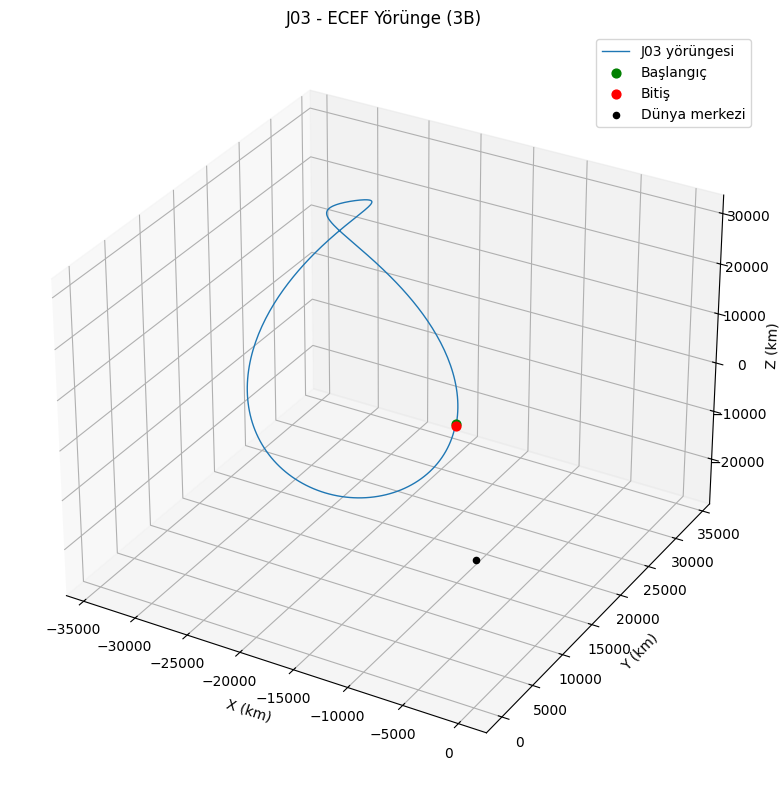

In [8]:
# --- 3 boyutlu yörünge (ECEF X-Y-Z, km cinsinden) ---
x_km = sat_df["X"] / 1000.0
y_km = sat_df["Y"] / 1000.0
z_km = sat_df["Z"] / 1000.0

fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(111, projection="3d")

ax.plot(x_km, y_km, z_km, color="tab:blue", linewidth=1.0, label=f"{TARGET_SAT} yörüngesi")
ax.scatter(x_km.iloc[0], y_km.iloc[0], z_km.iloc[0],
           color="green", s=40, label="Başlangıç")
ax.scatter(x_km.iloc[-1], y_km.iloc[-1], z_km.iloc[-1],
           color="red", s=40, label="Bitiş")

# Dünya merkezini referans olarak işaretle
ax.scatter(0, 0, 0, color="black", s=20, label="Dünya merkezi")

ax.set_title(f"{TARGET_SAT} - ECEF Yörünge (3B)")
ax.set_xlabel("X (km)")
ax.set_ylabel("Y (km)")
ax.set_zlabel("Z (km)")
ax.legend(loc="best")

plt.tight_layout()
plt.show()

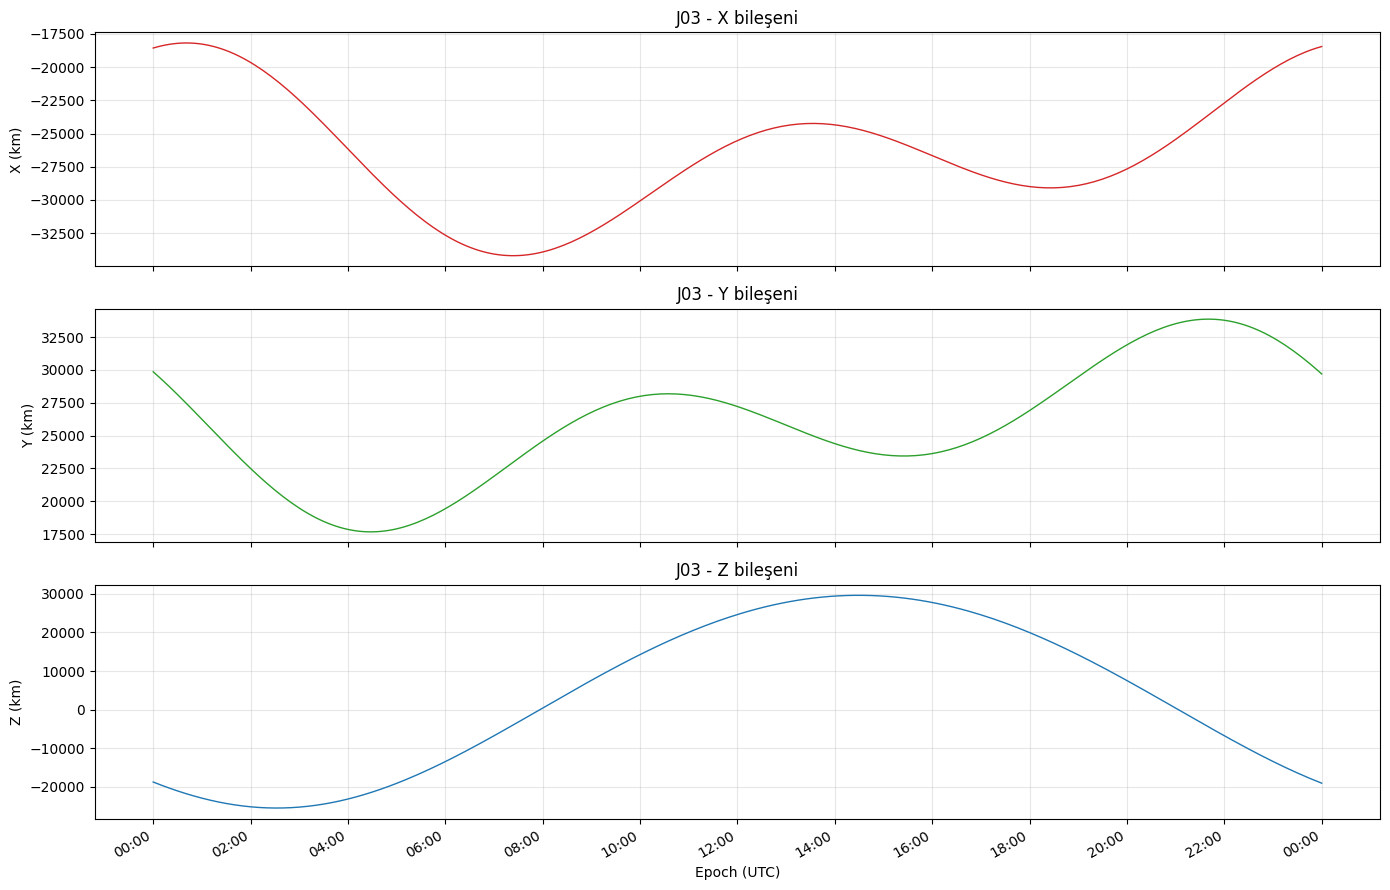

In [9]:
# --- X, Y, Z bileşenleri zamanla nasıl değişiyor? ---
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

components = [
    ("X", x_km, "tab:red"),
    ("Y", y_km, "tab:green"),
    ("Z", z_km, "tab:blue"),
]

for ax, (label, values, color) in zip(axes, components):
    ax.plot(sat_df["epoch"], values, color=color, linewidth=1.0)
    ax.set_ylabel(f"{label} (km)")
    ax.grid(True, alpha=0.3)
    ax.set_title(f"{TARGET_SAT} - {label} bileşeni")

axes[-1].set_xlabel("Epoch (UTC)")
axes[-1].xaxis.set_major_locator(mdates.HourLocator(interval=2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
fig.autofmt_xdate()

plt.tight_layout()
plt.show()